# 🚗 CARLA Unified Traffic Detection
### YOLOv8n · 8 classes · Jetson Nano 4GB optimised
**Datasets:** CARLA Roboflow + Traffic Violation Detection + COCO128  
**Detects:** person · vehicle · red light · green light · stop sign · speed limit 10 · speed limit 30 · turn right  
**Run order:** `0 → 1 → M → T → EXPORT → 2 → 3 → 4 → 5a / 5b`

## Cell 0 — Kaggle inputs

In [1]:
import kagglehub
from pathlib import Path

# Traffic Violation Detection Dataset
sign_ds_path = kagglehub.dataset_download('guisahanes/traffic-violation-detection-dataset')

# CARLA Roboflow dataset (your uploaded Kaggle dataset)
carla_ds_path = '/kaggle/input/datasets/nourchtourou22/carlao'   # adjust slug if different

print('✅  Inputs ready')
print(f'   Sign dataset  → {sign_ds_path}')
print(f'   CARLA dataset → {carla_ds_path}')

# Quick sanity check
for p in [sign_ds_path, carla_ds_path]:
    exists = Path(p).exists()
    print(f'   {"✅" if exists else "❌"}  {p}')

✅  Inputs ready
   Sign dataset  → /kaggle/input/datasets/guisahanes/traffic-violation-detection-dataset
   CARLA dataset → /kaggle/input/datasets/nourchtourou22/carlao
   ✅  /kaggle/input/datasets/guisahanes/traffic-violation-detection-dataset
   ✅  /kaggle/input/datasets/nourchtourou22/carlao


## Cell 1 — Install dependencies

In [2]:
import subprocess, sys
for pkg in ['ultralytics>=8.2', 'onnxruntime', 'opencv-python-headless', 'pyyaml']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)
print('✅  Dependencies ready — restart kernel if first run')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 90.6 MB/s eta 0:00:00
✅  Dependencies ready — restart kernel if first run


## Cell M — Build merged dataset

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL M — Merge CARLA + Traffic Violation + COCO128 into one clean dataset
#
#  TARGET CLASSES (8 only — focused for CARLA + Jetson Nano):
#    0: person
#    1: vehicle        (car, truck, bus, bike, motorbike — all merged)
#    2: red_light
#    3: green_light
#    4: stop_sign
#    5: speed_limit_10
#    6: speed_limit_30
#    7: turn_right
# ═══════════════════════════════════════════════════════════════════════════════
import yaml, shutil, random
from pathlib import Path
from collections import Counter

random.seed(42)

WORK     = Path('/kaggle/working/merged')
SIGN_DS  = Path(sign_ds_path)
CARLA_DS = Path(carla_ds_path)

# ── Unified classes ────────────────────────────────────────────────────────────
UNIFIED = [
    'person',           # 0
    'vehicle',          # 1
    'red_light',        # 2
    'green_light',      # 3
    'stop_sign',        # 4
    'speed_limit_10',   # 5
    'speed_limit_30',   # 6
    'turn_right',       # 7
]
NC = len(UNIFIED)

# ── CARLA class → unified ──────────────────────────────────────────────────────
CARLA_MAP = {
    0:  4,   # STOP       → stop_sign
    1:  1,   # bike       → vehicle
    2:  1,   # motobike   → vehicle
    3:  0,   # person     → person
    4:  3,   # tl_green   → green_light
             # 5 tl_orange → SKIP
    6:  2,   # tl_red     → red_light
    7:  5,   # sign_10    → speed_limit_10
             # 8 sign_20  → SKIP
    9:  6,   # sign_30    → speed_limit_30
             # 10/11      → SKIP
    12: 7,   # turn_right → turn_right
    13: 1,   # vehicle    → vehicle
}

# ── COCO class → unified ───────────────────────────────────────────────────────
COCO_MAP = {0: 0, 1: 1, 2: 1, 3: 1, 5: 1, 7: 1}

# ── Sign dataset → unified ─────────────────────────────────────────────────────
SIGN_MAP_KEYWORDS = {
    'red light': 2,   'red_light': 2,
    'green light': 3, 'green_light': 3,
    'stop sign': 4,   'stop_sign': 4,   'stop': 4,
    'turn right': 7,  'turn_right': 7,
}
SPEED_10_KW = ['10']
SPEED_30_KW = ['30']

# ── Helpers ────────────────────────────────────────────────────────────────────
def make_dirs(split):
    (WORK/'images'/split).mkdir(parents=True, exist_ok=True)
    (WORK/'labels'/split).mkdir(parents=True, exist_ok=True)

def remap_file(src_lbl, dst_lbl, id_map):
    lines_out = []
    try:
        for line in Path(src_lbl).read_text().strip().splitlines():
            parts = line.split()
            if not parts: continue
            old_id = int(parts[0])
            if old_id not in id_map: continue
            parts[0] = str(id_map[old_id])
            lines_out.append(' '.join(parts))
    except Exception:
        return 0
    if lines_out:
        Path(dst_lbl).write_text('\n'.join(lines_out) + '\n')
        return len(lines_out)
    return 0

def copy_split(src_imgs, src_lbls, dst_split, id_map, tag):
    n_img = n_lbl = n_ann = 0
    src_imgs = Path(src_imgs); src_lbls = Path(src_lbls)
    if not src_imgs.exists():
        print(f'  ⚠️  {tag}: images dir not found: {src_imgs}')
        return 0, 0
    for img in sorted(src_imgs.glob('*.*')):
        if img.suffix.lower() not in {'.jpg','.jpeg','.png','.bmp'}: continue
        dst_img = WORK/'images'/dst_split/img.name
        if dst_img.exists():
            dst_img = WORK/'images'/dst_split/(tag[:6]+'_'+img.name)
        shutil.copy2(img, dst_img); n_img += 1
        lbl = src_lbls / (img.stem + '.txt')
        if lbl.exists():
            n = remap_file(lbl, WORK/'labels'/dst_split/(dst_img.stem+'.txt'), id_map)  # ← fixed
            if n: n_lbl += 1; n_ann += n
    print(f'  [{tag:<30}] {dst_split:5s}: {n_img:4d} imgs  {n_lbl:4d} lbls  {n_ann:5d} ann')
    return n_img, n_lbl

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — CARLA dataset
# ══════════════════════════════════════════════════════════════════════════════
print('━'*66)
print('STEP 1 — CARLA Roboflow dataset')
print('━'*66)
print(f'  Root: {CARLA_DS}')

carla_contents = [p.name for p in CARLA_DS.iterdir()] if CARLA_DS.exists() else []
print(f'  Contents: {carla_contents}')

all_carla_imgs = []
found = False

for img_dir in sorted(CARLA_DS.rglob('images')):
    if not img_dir.is_dir(): continue
    lbl_dir = img_dir.parent / 'labels'
    if not lbl_dir.exists(): continue
    imgs = sorted(img_dir.glob('*.*'))
    all_carla_imgs.extend([(img, lbl_dir) for img in imgs
                           if img.suffix.lower() in {'.jpg','.jpeg','.png','.bmp'}])
    found = True

if not found:
    img_dir = CARLA_DS/'images'; lbl_dir = CARLA_DS/'labels'
    if img_dir.exists() and lbl_dir.exists():
        imgs = sorted(img_dir.glob('*.*'))
        all_carla_imgs = [(img, lbl_dir) for img in imgs
                          if img.suffix.lower() in {'.jpg','.jpeg','.png','.bmp'}]
        found = True

if not found:
    for split_dir in CARLA_DS.iterdir():
        if not split_dir.is_dir(): continue
        img_dir = split_dir/'images'; lbl_dir = split_dir/'labels'
        if img_dir.exists() and lbl_dir.exists():
            imgs = sorted(img_dir.glob('*.*'))
            all_carla_imgs.extend([(img, lbl_dir) for img in imgs
                                   if img.suffix.lower() in {'.jpg','.jpeg','.png','.bmp'}])
            found = True

print(f'  Total CARLA images found: {len(all_carla_imgs)}')

# 80/20 train/val split (CARLA only has train)
random.shuffle(all_carla_imgs)
n_val = max(1, len(all_carla_imgs) // 5)
carla_splits = {'val': all_carla_imgs[:n_val], 'train': all_carla_imgs[n_val:]}

for sp, pairs in carla_splits.items():
    make_dirs(sp)
    n_img = n_lbl = n_ann = 0
    for img, lbl_dir in pairs:
        dst_img = WORK/'images'/sp/img.name
        if dst_img.exists():
            dst_img = WORK/'images'/sp/('carla_'+img.name)
        shutil.copy2(img, dst_img); n_img += 1
        lbl = lbl_dir / (img.stem + '.txt')
        if lbl.exists():
            n = remap_file(lbl, WORK/'labels'/sp/(dst_img.stem+'.txt'), CARLA_MAP)  # ← fixed
            if n: n_lbl += 1; n_ann += n
    print(f'  [{"carla":30s}] {sp:5s}: {n_img:4d} imgs  {n_lbl:4d} lbls  {n_ann:5d} ann')

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Traffic Violation Detection Dataset
# ══════════════════════════════════════════════════════════════════════════════
print()
print('━'*66)
print('STEP 2 — Traffic Violation Detection Dataset (signs)')
print('━'*66)

yaml_path = next(SIGN_DS.rglob('data.yaml'), None)
if yaml_path is None:
    print(f'  ❌ data.yaml not found in {SIGN_DS}')
else:
    with open(yaml_path) as f:
        sign_cfg = yaml.safe_load(f)
    raw_names = sign_cfg.get('names', [])
    sign_names = [raw_names[k] for k in sorted(raw_names)] if isinstance(raw_names, dict) else list(raw_names)
    print(f'  Sign classes ({len(sign_names)}): {sign_names}')

    sign_map = {}
    for i, name in enumerate(sign_names):
        nl = name.lower().strip()
        if nl in SIGN_MAP_KEYWORDS:
            sign_map[i] = SIGN_MAP_KEYWORDS[nl]
        elif any(k in nl for k in SPEED_10_KW) and 'speed' in nl:
            sign_map[i] = 5
        elif any(k in nl for k in SPEED_30_KW) and 'speed' in nl:
            sign_map[i] = 6

    print(f'  Mapped: { {sign_names[i]: UNIFIED[v] for i,v in sign_map.items()} }')

    # Try structured split first: images/train/ labels/train/
    si_train = SIGN_DS/'images'/'train'
    if si_train.exists():
        for split in ('train', 'val'):
            si = SIGN_DS/'images'/split
            sl = SIGN_DS/'labels'/split
            if si.exists():
                make_dirs(split)
                copy_split(si, sl, split, sign_map, f'sign-{split}')
    else:
        # Flat structure: images/ labels/ — auto split 80/20
        si_flat = SIGN_DS/'images'; sl_flat = SIGN_DS/'labels'
        if si_flat.exists():
            all_sign = sorted([p for p in si_flat.glob('*.*')
                               if p.suffix.lower() in {'.jpg','.jpeg','.png','.bmp'}])
            random.shuffle(all_sign)
            nv = max(1, len(all_sign)//5)
            sets = {'val': all_sign[:nv], 'train': all_sign[nv:]}
            for sp2, imgs in sets.items():
                make_dirs(sp2)
                n_i = n_l = n_a = 0
                for img in imgs:
                    dst_img = WORK/'images'/sp2/img.name
                    if dst_img.exists():
                        dst_img = WORK/'images'/sp2/('sign_'+img.name)
                    shutil.copy2(img, dst_img); n_i += 1
                    lbl = sl_flat/(img.stem+'.txt')
                    if lbl.exists():
                        n = remap_file(lbl, WORK/'labels'/sp2/(dst_img.stem+'.txt'), sign_map)  # ← fixed
                        if n: n_l += 1; n_a += n
                print(f'  [{"sign-flat":30s}] {sp2:5s}: {n_i:4d} imgs  {n_l:4d} lbls  {n_a:5d} ann')

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — COCO128
# ══════════════════════════════════════════════════════════════════════════════
print()
print('━'*66)
print('STEP 3 — COCO128 (vehicle & person diversity)')
print('━'*66)

try:
    import subprocess, sys as _sys
    from ultralytics.utils import DATASETS_DIR
    coco128 = DATASETS_DIR/'coco128'
    if not coco128.exists():
        subprocess.run([_sys.executable, '-c',
            'from ultralytics.data.utils import check_det_dataset; check_det_dataset("coco128.yaml")'],
            capture_output=True)
    if coco128.exists():
        all_coco = sorted((coco128/'images'/'train2017').glob('*.jpg'))
        random.shuffle(all_coco)
        nv = max(1, len(all_coco)//10)
        coco_splits = {'val': all_coco[:nv], 'train': all_coco[nv:]}
        for sp, imgs in coco_splits.items():
            make_dirs(sp)
            n_i = n_l = n_a = 0
            for img in imgs:
                lbl = coco128/'labels'/'train2017'/(img.stem+'.txt')
                dst_img = WORK/'images'/sp/img.name
                if dst_img.exists():
                    dst_img = WORK/'images'/sp/('coco_'+img.name)
                shutil.copy2(img, dst_img); n_i += 1
                if lbl.exists():
                    n = remap_file(lbl, WORK/'labels'/sp/(dst_img.stem+'.txt'), COCO_MAP)  # ← fixed
                    if n: n_l += 1; n_a += n
            print(f'  [{"coco128":30s}] {sp:5s}: {n_i:4d} imgs  {n_l:4d} lbls  {n_a:5d} ann')
    else:
        print('  ⚠️  coco128 unavailable — skipping')
except Exception as e:
    print(f'  ⚠️  COCO skipped: {e}')

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — Write data.yaml
# ══════════════════════════════════════════════════════════════════════════════
print()
print('━'*66)
print('STEP 4 — Writing data.yaml')
print('━'*66)

unified_yaml = WORK/'data.yaml'
with open(unified_yaml, 'w') as f:
    yaml.dump({'path': str(WORK), 'train': 'images/train', 'val': 'images/val',
               'nc': NC, 'names': UNIFIED}, f, allow_unicode=True, sort_keys=False)
print(f'  Written → {unified_yaml}')

# ══════════════════════════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
print()
print('━'*66)
print('DATASET SUMMARY')
print('━'*66)
for sp in ('train', 'val'):
    imgs = list((WORK/'images'/sp).glob('*.*'))
    lbls = [l for l in (WORK/'labels'/sp).glob('*.txt') if l.stat().st_size > 0]
    print(f'  {sp:5s}: {len(imgs):5d} images | {len(lbls):5d} labelled')

print()
print('  Class distribution (train):')
counts = Counter()
for lbl in (WORK/'labels'/'train').glob('*.txt'):
    for line in lbl.read_text().strip().splitlines():
        if line.strip():
            try: counts[int(line.split()[0])] += 1
            except: pass
for cid, cnt in sorted(counts.items()):
    name = UNIFIED[cid] if cid < NC else f'UNKNOWN({cid})'
    bar  = '█' * min(50, cnt//10)
    print(f'  [{cid}] {name:<18} {cnt:5d}  {bar}')

print(f'\n✅  Dataset ready → {unified_yaml}')
print('   ➡  Run Cell T')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STEP 1 — CARLA Roboflow dataset
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Root: /kaggle/input/datasets/nourchtourou22/carlao
  Contents: ['README.roboflow.txt', 'data.yaml', 'train']
  Total CARLA images found: 832
  [carla                         ] val  :  166 imgs   144 lbls    321 ann
  [carla                         ] train:  666 imgs   590 lbls   1282 ann

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STEP 2 — Traffic Violation Detection Dataset (signs)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Sign classes (23): ['person', 'car', 'truck', 'bus', 'motorcycle', 'red light', 'green light', 'stop sign', 'no entry', 'no overtaking', 'speed limit 20', 'speed limit 30', 'speed limit 40', 'speed limit 50', 'speed limit 60', 'speed limit 70', 'speed limit 80', 'speed limit 100', 'speed limit 120', 'no left turn', 'no right turn', 'no stopping', 'no 

## Cell T — Train

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL T — Train YOLOv8n — 8 classes — Jetson Nano optimised
# ═══════════════════════════════════════════════════════════════════════════════
from pathlib import Path
from ultralytics import YOLO
import torch

DATASET_YAML = '/kaggle/working/merged/data.yaml'
BASE_WEIGHTS = 'yolov8n.pt'      # nano = fastest on Jetson 4GB
TRAIN_EPOCHS = 150
TRAIN_IMGSZ  = 416               # sweet spot for Jetson Nano (faster than 640)
TRAIN_BATCH  = 32                # lower to 16 if OOM
TRAIN_NAME   = 'carla_unified'

assert Path(DATASET_YAML).exists(), 'Run Cell M first'
print(f'🚀  YOLOv8n | {TRAIN_EPOCHS} epochs | imgsz={TRAIN_IMGSZ} | GPU={torch.cuda.is_available()}')

model   = YOLO(BASE_WEIGHTS)
results = model.train(
    data    = DATASET_YAML,
    epochs  = TRAIN_EPOCHS,
    imgsz   = TRAIN_IMGSZ,
    batch   = TRAIN_BATCH,
    name    = TRAIN_NAME,
    exist_ok= True,
    verbose = True,

    # ── Optimizer ─────────────────────────────────────────────────────────────
    optimizer     = 'AdamW',
    lr0           = 0.001,
    lrf           = 0.01,
    warmup_epochs = 5,
    weight_decay  = 0.0005,
    patience      = 30,

    # ── Augmentation tuned for CARLA synthetic + real images ──────────────────
    mosaic     = 1.0,    # paste 4 images — critical for small signs
    mixup      = 0.1,    # bridges real↔synthetic domain gap
    copy_paste = 0.1,
    hsv_h      = 0.02,
    hsv_s      = 0.7,
    hsv_v      = 0.4,
    degrees    = 5.0,
    translate  = 0.1,
    scale      = 0.6,    # signs appear at many distances in CARLA
    fliplr     = 0.5,
    flipud     = 0.0,    # no vertical flip for traffic scenes
    erasing    = 0.3,

    # ── Loss weights ──────────────────────────────────────────────────────────
    box  = 7.5,
    cls  = 0.5,
    dfl  = 1.5,

    cache = True,        # cache images for faster training on Kaggle
    half  = False,       # train FP32, quantise at export
)

best_pt = Path(results.save_dir) / 'weights' / 'best.pt'
assert best_pt.exists(), f'best.pt not found at {best_pt}'
COMBINED_PT = str(best_pt)

print(f'\n✅  Training complete')
print(f'    best.pt  → {best_pt}')
m50    = results.results_dict.get("metrics/mAP50(B)",    "N/A")
m5095  = results.results_dict.get("metrics/mAP50-95(B)", "N/A")
print(f'    mAP50    → {m50}')
print(f'    mAP50-95 → {m5095}')
print('\n   ➡  Run Cell EXPORT')

🚀  YOLOv8n | 150 epochs | imgsz=416 | GPU=True
Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/merged/data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.3, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=carla_unified, nbs=64, nms=False, opset=None, optimiz

## Cell EXPORT — Jetson Nano exports

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL EXPORT — ONNX (run everywhere) + TensorRT instructions for Jetson Nano
# ═══════════════════════════════════════════════════════════════════════════════
from pathlib import Path
from ultralytics import YOLO

assert Path(COMBINED_PT).exists(), 'Run Cell T first'
print(f'📦  Exporting: {COMBINED_PT}')

# 1. ONNX — runs on Jetson via onnxruntime-gpu without TensorRT setup
print('\n1/2  ONNX export...')
onnx_path = YOLO(COMBINED_PT).export(
    format='onnx', imgsz=416, simplify=True, dynamic=False, opset=12)
print(f'     ✅  {onnx_path}')

# 2. Validate ONNX
print('\n2/2  Validating ONNX...')
try:
    v = YOLO(str(onnx_path)).val(data='/kaggle/working/merged/data.yaml', imgsz=416)
    print(f'     mAP50    → {v.results_dict.get("metrics/mAP50(B)",0):.4f}')
    print(f'     mAP50-95 → {v.results_dict.get("metrics/mAP50-95(B)",0):.4f}')
except Exception as e:
    print(f'     ⚠️  {e}')

print()
print('═'*66)
print('  FILES TO COPY TO JETSON NANO:')
print(f'    {COMBINED_PT}')
print(f'    {onnx_path}')
print()
print('  ON THE JETSON NANO (one-time TensorRT export):')
print('    from ultralytics import YOLO')
print("    model = YOLO('best.onnx')")
print("    model.export(format='engine', half=True, imgsz=416, device=0)")
print("    # Then use: model = YOLO('best.engine')")
print('═'*66)

📦  Exporting: /kaggle/working/runs/detect/carla_unified/weights/best.pt

1/2  ONNX export...
Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/kaggle/working/runs/detect/carla_unified/weights/best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 12, 3549) (5.9 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 245ms
 Downloaded onnxruntime-gpu
Prepared 2 packages in 2.69s
Installed 2 packages in 114ms
 + onnxruntime-gpu==1.25.1
 + onnxslim==0.1.92

requirements: AutoUpdate success ✅ 3.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates t

## Cell 2 — Config

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Config
# ═══════════════════════════════════════════════════════════════════════════════
# COMBINED_PT is set automatically by Cell T
# Uncomment below only if loading a pre-existing model:
# COMBINED_PT = '/kaggle/working/runs/detect/carla_unified/weights/best.pt'

SOURCE     = 'https://source.roboflow.com/6n1NyzsuQFPAkTfwNZPOFv7lRDi1/03tzcORd4OZdOp2t1XpR/original.jpg'   # image path, video path, URL, or 0 for webcam
CONF_THRES = 0.30
IOU_THRES  = 0.45
IMGSZ      = 416
SAVE_VIDEO = True
print('✅  Config ready')

✅  Config ready


## Cell 3 — Detection engine

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Detection engine
# ═══════════════════════════════════════════════════════════════════════════════
import cv2, numpy as np, time, logging
from pathlib import Path
from datetime import datetime

logging.basicConfig(level=logging.INFO, format='[%(levelname)s] %(message)s')
log = logging.getLogger(__name__)

UNIFIED_CLASSES = [
    'person','vehicle','red_light','green_light',
    'stop_sign','speed_limit_10','speed_limit_30','turn_right',
]

CLASS_COLORS = {
    'person'        : (50,  205, 50),
    'vehicle'       : (0,   200, 255),
    'red_light'     : (0,   0,   255),
    'green_light'   : (0,   200, 0),
    'stop_sign'     : (0,   50,  255),
    'speed_limit_10': (0,   215, 255),
    'speed_limit_30': (0,   200, 245),
    'turn_right'    : (255, 128, 0),
}

VEHICLE_CLASSES = {'person', 'vehicle'}
SIGN_CLASSES    = {'red_light', 'stop_sign'}

def load_model(pt_path):
    from ultralytics import YOLO
    import torch
    dev = 0 if torch.cuda.is_available() else 'cpu'
    log.info(f'Loading: {pt_path}')
    m = YOLO(str(pt_path))
    log.info(f'✅  Ready | {len(m.names)} classes | device={dev}')
    return m, dev

def infer_all(model, dev, frame):
    import torch
    r = model.predict(frame, conf=CONF_THRES, iou=IOU_THRES, imgsz=IMGSZ,
                      device=dev, half=(dev==0 and torch.cuda.is_available()),
                      verbose=False)[0]
    dets = []
    for b in r.boxes:
        cid  = int(b.cls[0])
        name = model.names.get(cid, f'cls{cid}')
        dets.append({'bbox': tuple(b.xyxy[0].tolist()),
                     'class_id': cid, 'class_name': name,
                     'confidence': float(b.conf[0])})
    return dets

class ViolationDetector:
    ZM = 0.18
    VMAP = {'red_light': 'Red Light Running', 'stop_sign': 'Stop Sign Ignored'}
    VCOL = {'Red Light Running': (0,0,255), 'Stop Sign Ignored': (0,50,255)}

    def __init__(self): self.violations = []

    def detect(self, dets, fw, fh):
        self.violations = []
        signs = [d for d in dets if d['class_name'] in SIGN_CLASSES]
        vehs  = [d for d in dets if d['class_name'] in VEHICLE_CLASSES]
        for s in signs:
            x1,y1,x2,y2 = s['bbox']
            zx1=max(0,x1-fw*self.ZM); zy1=max(0,y1-fh*self.ZM)
            zx2=min(fw,x2+fw*self.ZM); zy2=min(fh,y2+fh*self.ZM)
            for v in vehs:
                vx1,vy1,vx2,vy2 = v['bbox']
                if vx1<zx2 and vx2>zx1 and vy1<zy2 and vy2>zy1:
                    vt = self.VMAP.get(s['class_name'])
                    if vt: self.violations.append({'type':vt,'vehicle':v,'sign':s})
        return self.violations

    def draw(self, frame):
        for v in self.violations:
            c = self.VCOL.get(v['type'],(0,0,255))
            x1,y1,x2,y2 = (int(x) for x in v['vehicle']['bbox'])
            cv2.rectangle(frame,(x1-3,y1-3),(x2+3,y2+3),c,4)
            lbl = f'VIOLATION: {v["type"]}'
            (tw,th),_ = cv2.getTextSize(lbl,cv2.FONT_HERSHEY_SIMPLEX,.55,2)
            lx,ly = max(0,x1), max(th+10,y1-12)
            cv2.rectangle(frame,(lx,ly-th-6),(lx+tw+6,ly),c,-1)
            cv2.putText(frame,lbl,(lx+3,ly-3),cv2.FONT_HERSHEY_SIMPLEX,.55,(255,255,255),2,cv2.LINE_AA)
        return frame

def draw_boxes(frame, dets):
    for d in dets:
        x1,y1,x2,y2 = (int(v) for v in d['bbox'])
        c   = CLASS_COLORS.get(d['class_name'],(128,128,128))
        lbl = f'{d["class_name"]} {d["confidence"]:.2f}'
        cv2.rectangle(frame,(x1,y1),(x2,y2),c,2)
        (tw,th),_ = cv2.getTextSize(lbl,cv2.FONT_HERSHEY_SIMPLEX,.5,1)
        cv2.rectangle(frame,(x1,max(0,y1-th-8)),(x1+tw+6,y1),c,-1)
        cv2.putText(frame,lbl,(x1+3,y1-4),cv2.FONT_HERSHEY_SIMPLEX,.5,(255,255,255),1,cv2.LINE_AA)
    return frame

def draw_hud(frame, fps, nd, nv, backend='Unified'):
    h,w = frame.shape[:2]
    ov = frame.copy()
    cv2.rectangle(ov,(0,0),(w,46),(15,15,15),-1)
    cv2.addWeighted(ov,.65,frame,.35,0,frame)
    cv2.putText(frame,f'FPS:{fps:5.1f}',(10,32),cv2.FONT_HERSHEY_SIMPLEX,.75,(0,255,80),2,cv2.LINE_AA)
    cv2.putText(frame,f'Det:{nd}',(165,32),cv2.FONT_HERSHEY_SIMPLEX,.75,(255,220,0),2,cv2.LINE_AA)
    vc = (0,0,255) if nv else (160,160,160)
    cv2.putText(frame,f'Violations:{nv}',(265,32),cv2.FONT_HERSHEY_SIMPLEX,.75,vc,2,cv2.LINE_AA)
    cv2.putText(frame,backend,(max(10,w-200),32),cv2.FONT_HERSHEY_SIMPLEX,.5,(150,150,255),1,cv2.LINE_AA)
    return frame

def load_frame(src):
    s = str(src)
    if s.startswith('http://') or s.startswith('https://'):
        import urllib.request
        resp = urllib.request.urlopen(s)
        arr  = np.asarray(bytearray(resp.read()), dtype=np.uint8)
        return cv2.imdecode(arr, cv2.IMREAD_COLOR)
    return cv2.imread(s)

print('✅  Detection engine ready')
print(f'   Classes: {UNIFIED_CLASSES}')

✅  Detection engine ready
   Classes: ['person', 'vehicle', 'red_light', 'green_light', 'stop_sign', 'speed_limit_10', 'speed_limit_30', 'turn_right']


## Cell 4 — Load model

In [8]:
from pathlib import Path
unified_model, unified_device = load_model(COMBINED_PT)
violator = ViolationDetector()
Path('snapshots').mkdir(exist_ok=True)
print(f'✅  {len(unified_model.names)} classes | device={unified_device}')
print(f'   Classes: {list(unified_model.names.values())}')
print('\n   ➡  Run Cell 5a (image) or Cell 5b (video)')

[INFO] Loading: /kaggle/working/runs/detect/carla_unified/weights/best.pt
[INFO] ✅  Ready | 8 classes | device=0


✅  8 classes | device=0
   Classes: ['person', 'vehicle', 'red_light', 'green_light', 'stop_sign', 'speed_limit_10', 'speed_limit_30', 'turn_right']

   ➡  Run Cell 5a (image) or Cell 5b (video)


## Cell 5a — Test on image

✅ 3 detections | 1 violations
   [ 1] vehicle          conf=0.892
   [ 1] vehicle          conf=0.843
   [ 2] red_light        conf=0.426
   ⚠️  Red Light Running


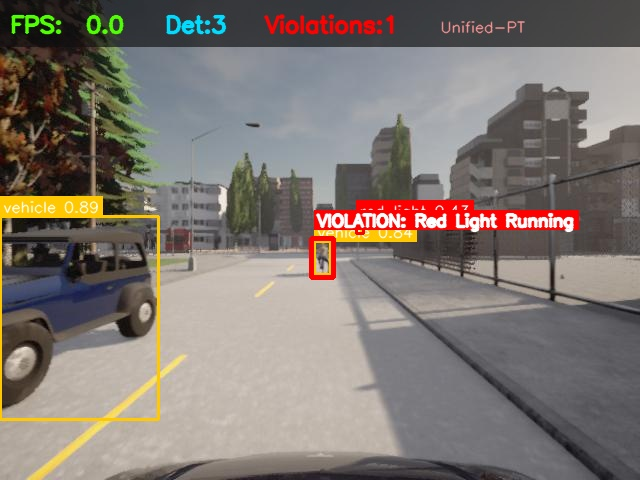

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5a — Run on IMAGE (URL or local path)
# ═══════════════════════════════════════════════════════════════════════════════
import cv2, numpy as np, urllib.request

IMAGE_PATH = 'https://source.roboflow.com/6n1NyzsuQFPAkTfwNZPOFv7lRDi1/03tzcORd4OZdOp2t1XpR/original.jpg'

# Load from URL or local file
if IMAGE_PATH.startswith('http'):
    resp      = urllib.request.urlopen(IMAGE_PATH)
    img_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    frame     = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
else:
    frame = cv2.imread(IMAGE_PATH)

if frame is None:
    print(f'❌ Cannot read: {IMAGE_PATH}')
else:
    h0, w0 = frame.shape[:2]
    dets   = infer_all(unified_model, unified_device, frame)   # ← fixed
    viols  = violator.detect(dets, w0, h0)
    out    = draw_boxes(frame.copy(), dets)
    out    = violator.draw(out)
    out    = draw_hud(out, 0, len(dets), len(viols), 'Unified-PT')
    cv2.imwrite('detected_output.jpg', out)

    print(f'✅ {len(dets)} detections | {len(viols)} violations')
    for d in dets:
        print(f'   [{d["class_id"]:>2}] {d["class_name"]:<16} conf={d["confidence"]:.3f}')
    for v in viols:
        print(f'   ⚠️  {v["type"]}')

    from IPython.display import display, Image as IPImg
    display(IPImg('detected_output.jpg', width=900))

## Cell 5b — Test on video / webcam

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5b — Video / webcam inference
# ═══════════════════════════════════════════════════════════════════════════════
import cv2, time
from datetime import datetime

src = int(SOURCE) if str(SOURCE).isdigit() else str(SOURCE)
cap = cv2.VideoCapture(src)
if not cap.isOpened():
    print(f'❌  Cannot open: {SOURCE}')
else:
    w0  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h0  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    print(f'▶  {w0}×{h0} @ {fps:.0f} FPS | press Q to quit, S to snapshot')

    writer = None
    if SAVE_VIDEO:
        writer = cv2.VideoWriter('traffic_output.mp4',
                                 cv2.VideoWriter_fourcc(*'mp4v'), fps, (w0,h0))
    fps_buf=[]; fc=0; t0=time.time()
    while True:
        ret, frame = cap.read()
        if not ret: break
        t1    = time.perf_counter()
        dets  = infer_all(unified_model, unified_device, frame)
        viols = violator.detect(dets, w0, h0)
        dt    = time.perf_counter()-t1
        fps_buf.append(1/max(dt,1e-6))
        if len(fps_buf)>30: fps_buf.pop(0)
        out = draw_boxes(frame.copy(), dets)
        out = violator.draw(out)
        out = draw_hud(out, sum(fps_buf)/len(fps_buf), len(dets), len(viols))
        if writer: writer.write(out)
        try:
            cv2.imshow('Detection', out)
            k = cv2.waitKey(1)&0xFF
            if k==ord('q'): break
            elif k==ord('s'):
                ts=datetime.now().strftime('%Y%m%d_%H%M%S')
                cv2.imwrite(f'snapshots/snap_{ts}.jpg', out)
                print(f'  📸 snap_{ts}.jpg')
        except: pass
        fc+=1
    cap.release()
    if writer: writer.release()
    try: cv2.destroyAllWindows()
    except: pass
    el=time.time()-t0
    print(f'\n✅  {fc} frames | {el:.1f}s | {fc/max(el,1):.1f} FPS avg')
    if SAVE_VIDEO: print('   Saved → traffic_output.mp4')

▶  640×480 @ 25 FPS | press Q to quit, S to snapshot


## Cell JETSON — Deploy on Jetson Nano 4GB

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL JETSON — Save deploy script for Jetson Nano 4GB
#   1. Copy best.pt and best.onnx to your Jetson Nano
#   2. Run: python3 detect_jetson.py
# ═══════════════════════════════════════════════════════════════════════════════

script = '''#!/usr/bin/env python3
# ── Jetson Nano 4GB Traffic Detection ──────────────────────────────────────────
# Setup (once on Jetson):
#   pip3 install ultralytics onnxruntime-gpu opencv-python-headless
# For TensorRT (max speed):
#   from ultralytics import YOLO
#   YOLO("best.onnx").export(format="engine", half=True, imgsz=416, device=0)
# ─────────────────────────────────────────────────────────────────────────────
import time, cv2
from ultralytics import YOLO

MODEL  = "best.pt"       # or "best.onnx" or "best.engine" (TensorRT)
SOURCE = 0               # webcam; or path to video file
CONF   = 0.30
IMGSZ  = 416

CLASSES = [
    "person","vehicle","red_light","green_light",
    "stop_sign","speed_limit_10","speed_limit_30","turn_right",
]
COLORS = [
    (50,205,50),(0,200,255),(0,0,255),(0,200,0),
    (0,50,255),(0,215,255),(0,200,245),(255,128,0),
]

print(f"Loading {MODEL} ...")
model = YOLO(MODEL)
model.fuse()    # fuses conv+bn — faster inference on Nano

cap     = cv2.VideoCapture(SOURCE)
fps_buf = []
print("Running — press Q to quit")

while True:
    ret, frame = cap.read()
    if not ret: break

    t0 = time.perf_counter()
    results = model.predict(frame, conf=CONF, imgsz=IMGSZ, half=True, verbose=False)[0]
    dt = time.perf_counter() - t0

    fps_buf.append(1/max(dt,1e-6))
    if len(fps_buf)>20: fps_buf.pop(0)
    fps = sum(fps_buf)/len(fps_buf)

    for b in results.boxes:
        x1,y1,x2,y2 = (int(v) for v in b.xyxy[0])
        cid  = int(b.cls[0])
        name = CLASSES[cid] if cid < len(CLASSES) else str(cid)
        col  = COLORS[cid]  if cid < len(COLORS)  else (128,128,128)
        cv2.rectangle(frame,(x1,y1),(x2,y2),col,2)
        cv2.putText(frame,f"{name} {float(b.conf[0]):.2f}",
                    (x1,max(0,y1-8)),cv2.FONT_HERSHEY_SIMPLEX,.5,(255,255,255),1)

    cv2.putText(frame,f"FPS:{fps:.1f}",(10,30),cv2.FONT_HERSHEY_SIMPLEX,.8,(0,255,80),2)
    cv2.imshow("Jetson Nano",frame)
    if cv2.waitKey(1)&0xFF==ord("q"): break

cap.release()
cv2.destroyAllWindows()
'''

from pathlib import Path
Path('detect_jetson.py').write_text(script.strip())
print('✅  Saved → detect_jetson.py')
print()
print('  Steps to deploy on Jetson Nano 4GB:')
print('  1. scp detect_jetson.py best.pt user@jetson:~/')
print('  2. ssh user@jetson')
print('  3. pip3 install ultralytics onnxruntime-gpu opencv-python-headless')
print('  4. python3 detect_jetson.py')